# Task
Perform an analysis to determine if positive audience reactions improve content popularity, using the "raw.csv" dataset.

## Load Dataset

### Subtask:
Load the 'raw.csv' dataset into a pandas DataFrame to begin the analysis.


In [1]:
import pandas as pd
import numpy as np
from sklearn import datasets

df = pd.read_csv('raw.csv')
print("Dataset loaded successfully. Displaying the first 5 rows:")
df.head()

Dataset loaded successfully. Displaying the first 5 rows:


,post_id,platform,content_type,topic,language,region,post_datetime,hashtags,views,likes,comments,shares,engagement_rate,sentiment_score,is_viral
0,SM_100000,Instagram,text,Sports,ur,UK,2024-12-10 00:00:00,#tech #funny #music,2319102,122058,15800,861,0.0598,0.464,1
1,SM_100001,Instagram,carousel,Sports,ur,Brazil,2024-10-13 00:00:00,#news #fyp #funny #ai #trending,2538464,110368,11289,54887,0.0695,-0.800,1
2,SM_100002,YouTube Shorts,video,Technology,ur,UK,2024-05-03 00:00:00,#ai #news,1051176,87598,47196,44132,0.1702,0.416,0
3,SM_100003,X,text,Politics,ur,US,2024-08-04 00:00:00,#ai #funny,5271440,329465,774,59736,0.0740,0.877,1
4,SM_100004,YouTube Shorts,text,Education,es,US,2024-03-28 00:00:00,#news #ai #viral #funny #fyp,3186256,199141,5316,83105,0.0903,0.223,1


## Initial Data Inspection

### Subtask:
Perform an initial inspection of the dataset. This includes displaying the first few rows, checking data types with `.info()`, and reviewing basic descriptive statistics with `.describe()` to understand the data's structure and content.


In [2]:
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   post_id          2000 non-null   object 
 1   platform         2000 non-null   object 
 2   content_type     2000 non-null   object 
 3   topic            2000 non-null   object 
 4   language         2000 non-null   object 
 5   region           2000 non-null   object 
 6   post_datetime    2000 non-null   object 
 7   hashtags         2000 non-null   object 
 8   views            2000 non-null   int64  
 9   likes            2000 non-null   int64  
 10  comments         2000 non-null   int64  
 11  shares           2000 non-null   int64  
 12  engagement_rate  2000 non-null   float64
 13  sentiment_score  2000 non-null   float64
 14  is_viral         2000 non-null   int64  
dtypes: float64(2), int64(5), object(8)
memory usage: 234.5+ KB


In [3]:
print("\nDescriptive Statistics:")
df.describe()


Descriptive Statistics:


,views,likes,comments,shares,engagement_rate,sentiment_score,is_viral
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.284860e+06,245329.244000,24786.929000,49936.981500,0.157852,-0.000566,0.699000
std,3.246193e+06,145032.423582,14433.288364,29012.818697,0.535457,0.574911,0.458807
min,4.380000e+03,292.000000,14.000000,127.000000,0.035700,-1.000000,0.000000
25%,1.652742e+06,118903.750000,12337.750000,25698.750000,0.057975,-0.507000,0.000000
50%,3.469408e+06,239831.000000,24519.500000,50212.000000,0.084500,0.001000,1.000000
75%,6.348078e+06,372323.500000,37116.250000,75433.000000,0.142525,0.495250,1.000000
max,1.437179e+07,499983.000000,49989.000000,99977.000000,12.573200,0.999000,1.000000


## Handle Missing Values

### Subtask:
Identify and address any missing values in the dataset. This step will involve checking the count of nulls per column and deciding on an appropriate strategy (e.g., imputation, removal) based on the column's nature and the extent of missingness.


In [4]:
df.isnull().sum()

post_id            0
platform           0
content_type       0
topic              0
language           0
region             0
post_datetime      0
hashtags           0
views              0
likes              0
comments           0
shares             0
engagement_rate    0
sentiment_score    0
is_viral           0
dtype: int64

## Handle Duplicate Rows

### Subtask:
Check for and remove any duplicate rows from the dataset to ensure data uniqueness and prevent bias in the analysis.


In [6]:
print("Original DataFrame shape:", df.shape)
duplicate_rows_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows_count}")

if duplicate_rows_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed. New DataFrame shape:", df.shape)
else:
    print("No duplicate rows found.")

Original DataFrame shape: (2000, 15)
Number of duplicate rows found: 0
No duplicate rows found.


## Feature Engineering and Selection

### Subtask:
Based on the initial inspection and the hypothesis ('positive audience reactions improve content popularity'), identify and select suitable columns related to 'positive audience reactions' and 'views'. This might involve creating new features or dropping irrelevant columns.


In [7]:
df_cleaned = df.drop(columns=['post_id'])
print("Dropped 'post_id' column. Displaying the first 5 rows of the modified DataFrame:")
df_cleaned.head()

Dropped 'post_id' column. Displaying the first 5 rows of the modified DataFrame:


,platform,content_type,topic,language,region,post_datetime,hashtags,views,likes,comments,shares,engagement_rate,sentiment_score,is_viral
0,Instagram,text,Sports,ur,UK,2024-12-10 00:00:00,#tech #funny #music,2319102,122058,15800,861,0.0598,0.464,1
1,Instagram,carousel,Sports,ur,Brazil,2024-10-13 00:00:00,#news #fyp #funny #ai #trending,2538464,110368,11289,54887,0.0695,-0.800,1
2,YouTube Shorts,video,Technology,ur,UK,2024-05-03 00:00:00,#ai #news,1051176,87598,47196,44132,0.1702,0.416,0
3,X,text,Politics,ur,US,2024-08-04 00:00:00,#ai #funny,5271440,329465,774,59736,0.0740,0.877,1
4,YouTube Shorts,text,Education,es,US,2024-03-28 00:00:00,#news #ai #viral #funny #fyp,3186256,199141,5316,83105,0.0903,0.223,1


In [8]:
df = df_cleaned.copy()
print("DataFrame after dropping 'post_id' and assigning back to df. Current columns:")
print(df.columns.tolist())

print("\nIdentified columns for positive audience reactions: ['likes', 'comments', 'shares', 'engagement_rate', 'sentiment_score']")
print("Identified column for content popularity: ['views']")

DataFrame after dropping 'post_id' and assigning back to df. Current columns:
['platform', 'content_type', 'topic', 'language', 'region', 'post_datetime', 'hashtags', 'views', 'likes', 'comments', 'shares', 'engagement_rate', 'sentiment_score', 'is_viral']

Identified columns for positive audience reactions: ['likes', 'comments', 'shares', 'engagement_rate', 'sentiment_score']
Identified column for content popularity: ['views']


## Encode Categorical Features

### Subtask:
Identify categorical features and apply appropriate encoding techniques (e.g., One-Hot Encoding) to convert them into a numerical format suitable for correlation analysis and statistical modeling.


In [9]:
df['post_datetime'] = pd.to_datetime(df['post_datetime'])
print("Converted 'post_datetime' to datetime objects. Info for this column:")
df['post_datetime'].info()

Converted 'post_datetime' to datetime objects. Info for this column:
<class 'pandas.core.series.Series'>
RangeIndex: 2000 entries, 0 to 1999
Series name: post_datetime
Non-Null Count  Dtype         
--------------  -----         
2000 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 15.8 KB


In [10]:
categorical_cols = df.select_dtypes(include=['object']).columns

# Exclude 'hashtags' from one-hot encoding as it can generate too many columns and requires special handling.
# For this analysis, we will focus on other explicit categorical features.
categorical_cols = categorical_cols.drop('hashtags', errors='ignore')

print(f"Categorical columns to be one-hot encoded: {categorical_cols.tolist()}")

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nDataFrame after one-hot encoding. Displaying the first 5 rows:")
print(df_encoded.head())

print("\nDataFrame Info after one-hot encoding:")
df_encoded.info()

Categorical columns to be one-hot encoded: ['platform', 'content_type', 'topic', 'language', 'region']

DataFrame after one-hot encoding. Displaying the first 5 rows:
  post_datetime                         hashtags    views   likes  comments  \
0    2024-12-10              #tech #funny #music  2319102  122058     15800   
1    2024-10-13  #news #fyp #funny #ai #trending  2538464  110368     11289   
2    2024-05-03                        #ai #news  1051176   87598     47196   
3    2024-08-04                       #ai #funny  5271440  329465       774   
4    2024-03-28     #news #ai #viral #funny #fyp  3186256  199141      5316   

   shares  engagement_rate  sentiment_score  is_viral  platform_TikTok  ...  \
0     861           0.0598            0.464         1            False  ...   
1   54887           0.0695           -0.800         1            False  ...   
2   44132           0.1702            0.416         0            False  ...   
3   59736           0.0740            0.87

## Apply TF-IDF for Hashtags

### Subtask:
Apply TF-IDF (Term Frequency-Inverse Document Frequency) to the 'hashtags' column to extract numerical features representing the importance of each hashtag. This will enrich the dataset with features derived from textual content.


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Preprocess the 'hashtags' column
# Ensure all values are strings and concatenate them with spaces
# Remove '#' and split into individual words/phrases then join with space
def preprocess_hashtags(hashtags_str):
    if isinstance(hashtags_str, str):
        # Remove '#' characters and split by space, then join back with a single space
        # This handles cases like '#tag1 #tag2' -> 'tag1 tag2'
        # And also 'tag1#tag2' -> 'tag1 tag2' if needed, though input suggests spaces already
        clean_tags = [tag.strip() for tag in hashtags_str.replace('#', ' ').split() if tag.strip()]
        return ' '.join(clean_tags)
    return '' # Return empty string for non-string types to avoid errors

df_encoded['processed_hashtags'] = df_encoded['hashtags'].apply(preprocess_hashtags)

print("Preprocessed 'hashtags' column. Displaying first 5 rows of 'processed_hashtags':")
print(df_encoded[['hashtags', 'processed_hashtags']].head())

# Instantiate TfidfVectorizer
# Using a reasonable max_features to limit the number of columns, e.g., 100
tfidf_vectorizer = TfidfVectorizer(max_features=100, stop_words='english')

# Fit and transform the preprocessed 'hashtags' column
tfidf_matrix = tfidf_vectorizer.fit_transform(df_encoded['processed_hashtags'])

# Convert the TF-IDF sparse matrix into a pandas DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out(), index=df_encoded.index)

print(f"\nTF-IDF matrix converted to DataFrame with {tfidf_df.shape[1]} features. Displaying the first 5 rows:")
print(tfidf_df.head())

# Concatenate the new TF-IDF DataFrame with the df_encoded DataFrame
df_encoded = pd.concat([df_encoded, tfidf_df], axis=1)

# Drop the original 'hashtags' column and the 'processed_hashtags' column as they are no longer needed
df_encoded = df_encoded.drop(columns=['hashtags', 'processed_hashtags'])

print("\nDataFrame after TF-IDF and concatenation. Displaying the first 5 rows:")
print(df_encoded.head())

print("\nDataFrame Info after TF-IDF:")
df_encoded.info()

Preprocessed 'hashtags' column. Displaying first 5 rows of 'processed_hashtags':
                          hashtags          processed_hashtags
0              #tech #funny #music            tech funny music
1  #news #fyp #funny #ai #trending  news fyp funny ai trending
2                        #ai #news                     ai news
3                       #ai #funny                    ai funny
4     #news #ai #viral #funny #fyp     news ai viral funny fyp

TF-IDF matrix converted to DataFrame with 8 features. Displaying the first 5 rows:
         ai     funny       fyp     music      news      tech  trending  \
0  0.000000  0.574960  0.000000  0.570679  0.000000  0.586299  0.000000   
1  0.450354  0.444732  0.456692  0.000000  0.447246  0.000000  0.436804   
2  0.709551  0.000000  0.000000  0.000000  0.704654  0.000000  0.000000   
3  0.711534  0.702652  0.000000  0.000000  0.000000  0.000000  0.000000   
4  0.448789  0.443186  0.455104  0.000000  0.445691  0.000000  0.000000   

      

In [13]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   post_datetime            2000 non-null   datetime64[ns]
 1   views                    2000 non-null   int64         
 2   likes                    2000 non-null   int64         
 3   comments                 2000 non-null   int64         
 4   shares                   2000 non-null   int64         
 5   engagement_rate          2000 non-null   float64       
 6   sentiment_score          2000 non-null   float64       
 7   is_viral                 2000 non-null   int64         
 8   platform_TikTok          2000 non-null   bool          
 9   platform_X               2000 non-null   bool          
 10  platform_YouTube Shorts  2000 non-null   bool          
 11  content_type_image       2000 non-null   bool          
 12  content_type_text        2000 non-

In [12]:
# Save the preprocessed DataFrame to a CSV file
df_encoded.to_csv('preprocessed_data.csv', index=False)

# Provide a download link
from IPython.display import FileLink
FileLink('preprocessed_data.csv')

d:\TPSM\TPSM\niumi\preprocessed_data.csv

## Exploratory Data Analysis (EDA) - Distributions of Numerical Features

### Subtask:
Visualize the distributions of key numerical features such as 'views', 'likes', 'comments', 'shares', 'engagement_rate', and 'sentiment_score' using histograms and box plots to understand their spread, central tendency, and identify potential outliers.


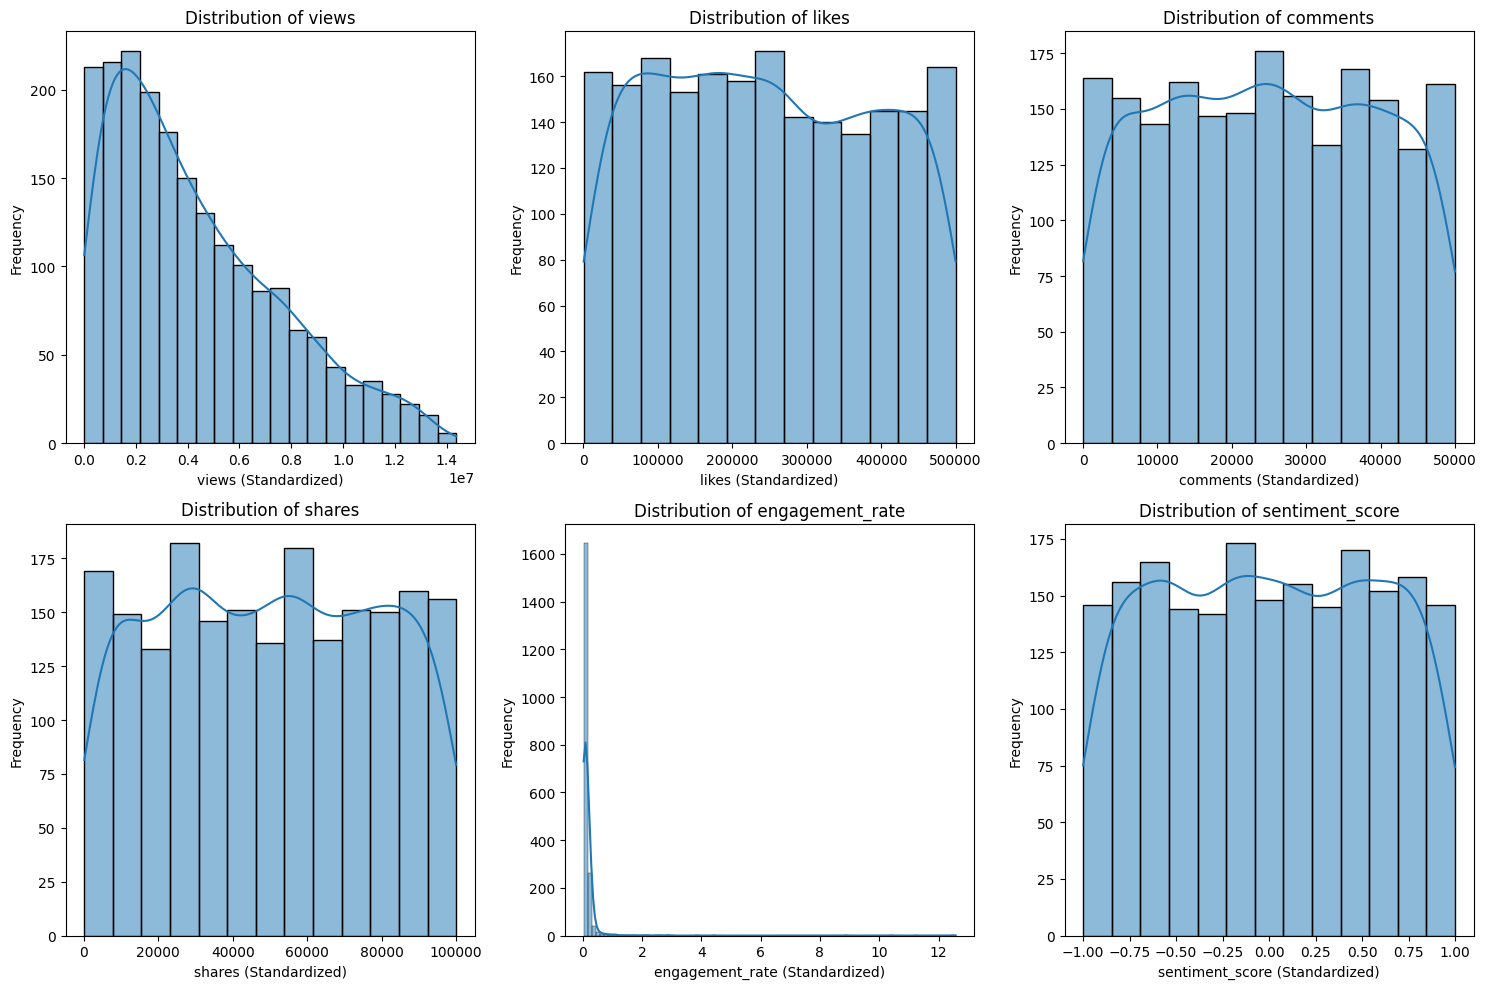

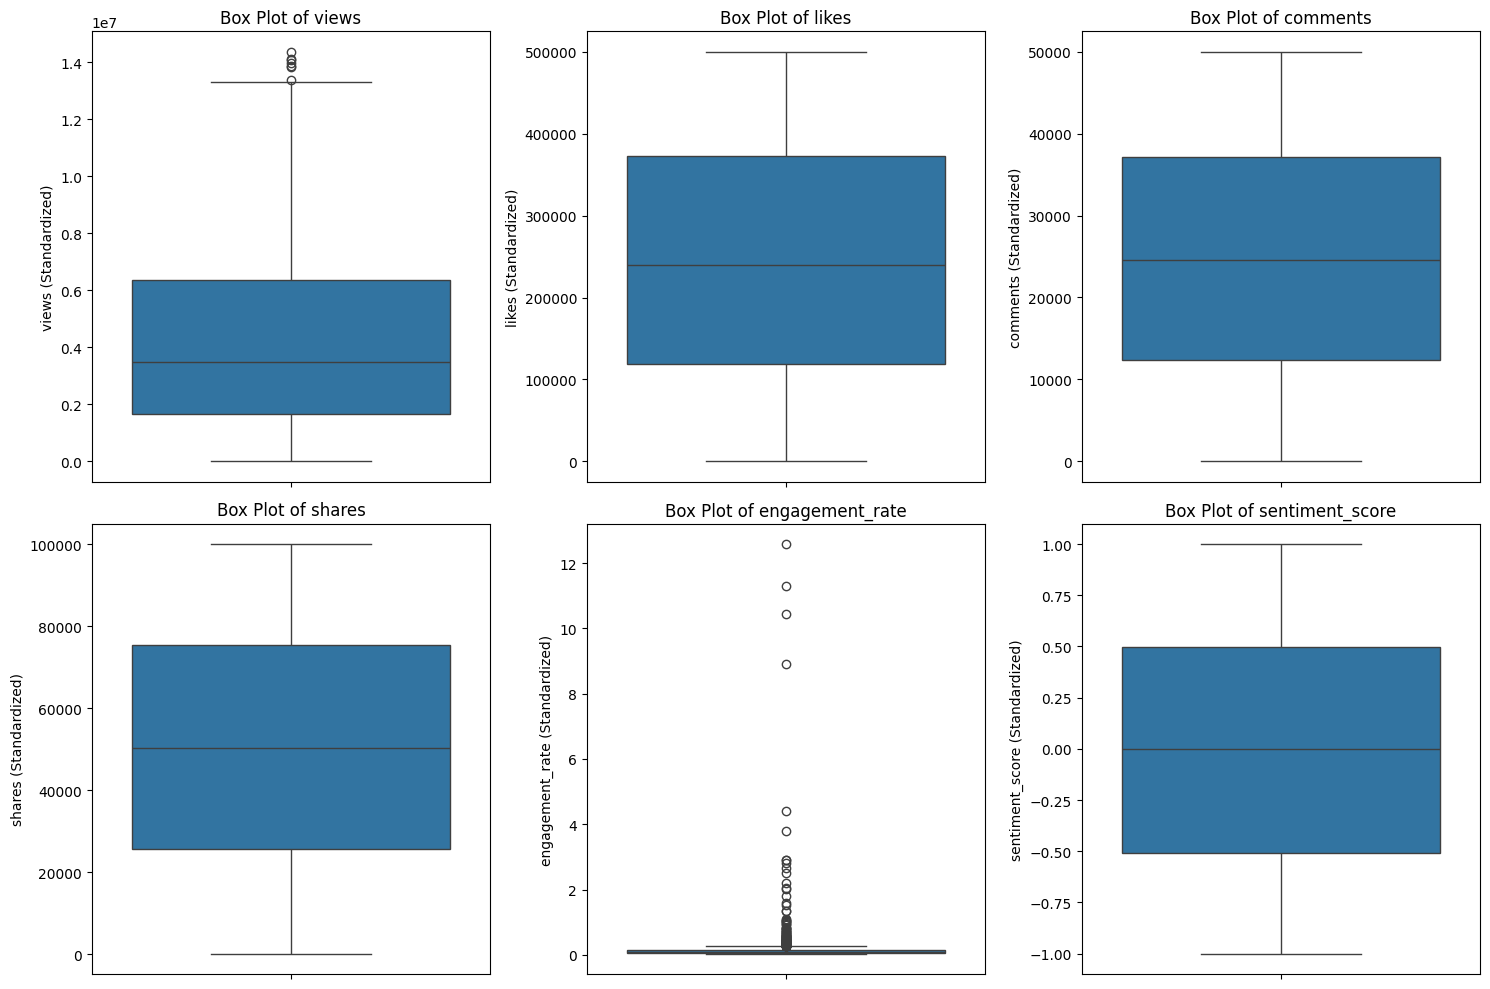

In [18]:
numerical_features = ['views', 'likes', 'comments', 'shares', 'engagement_rate', 'sentiment_score']

# Create histograms for numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df_encoded[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(f'{col} (Standardized)')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Create box plots for numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_encoded[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(f'{col} (Standardized)')
plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA) - Distributions of Categorical Features

### Subtask:
Visualize the distributions of categorical features like 'platform', 'content_type', 'topic', 'language', and 'region' using bar plots to understand the frequency of each category.


C:\Users\niumi600053\AppData\Local\Temp\ipykernel_6008\55665149.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
C:\Users\niumi600053\AppData\Local\Temp\ipykernel_6008\55665149.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
C:\Users\niumi600053\AppData\Local\Temp\ipykernel_6008\55665149.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='virid

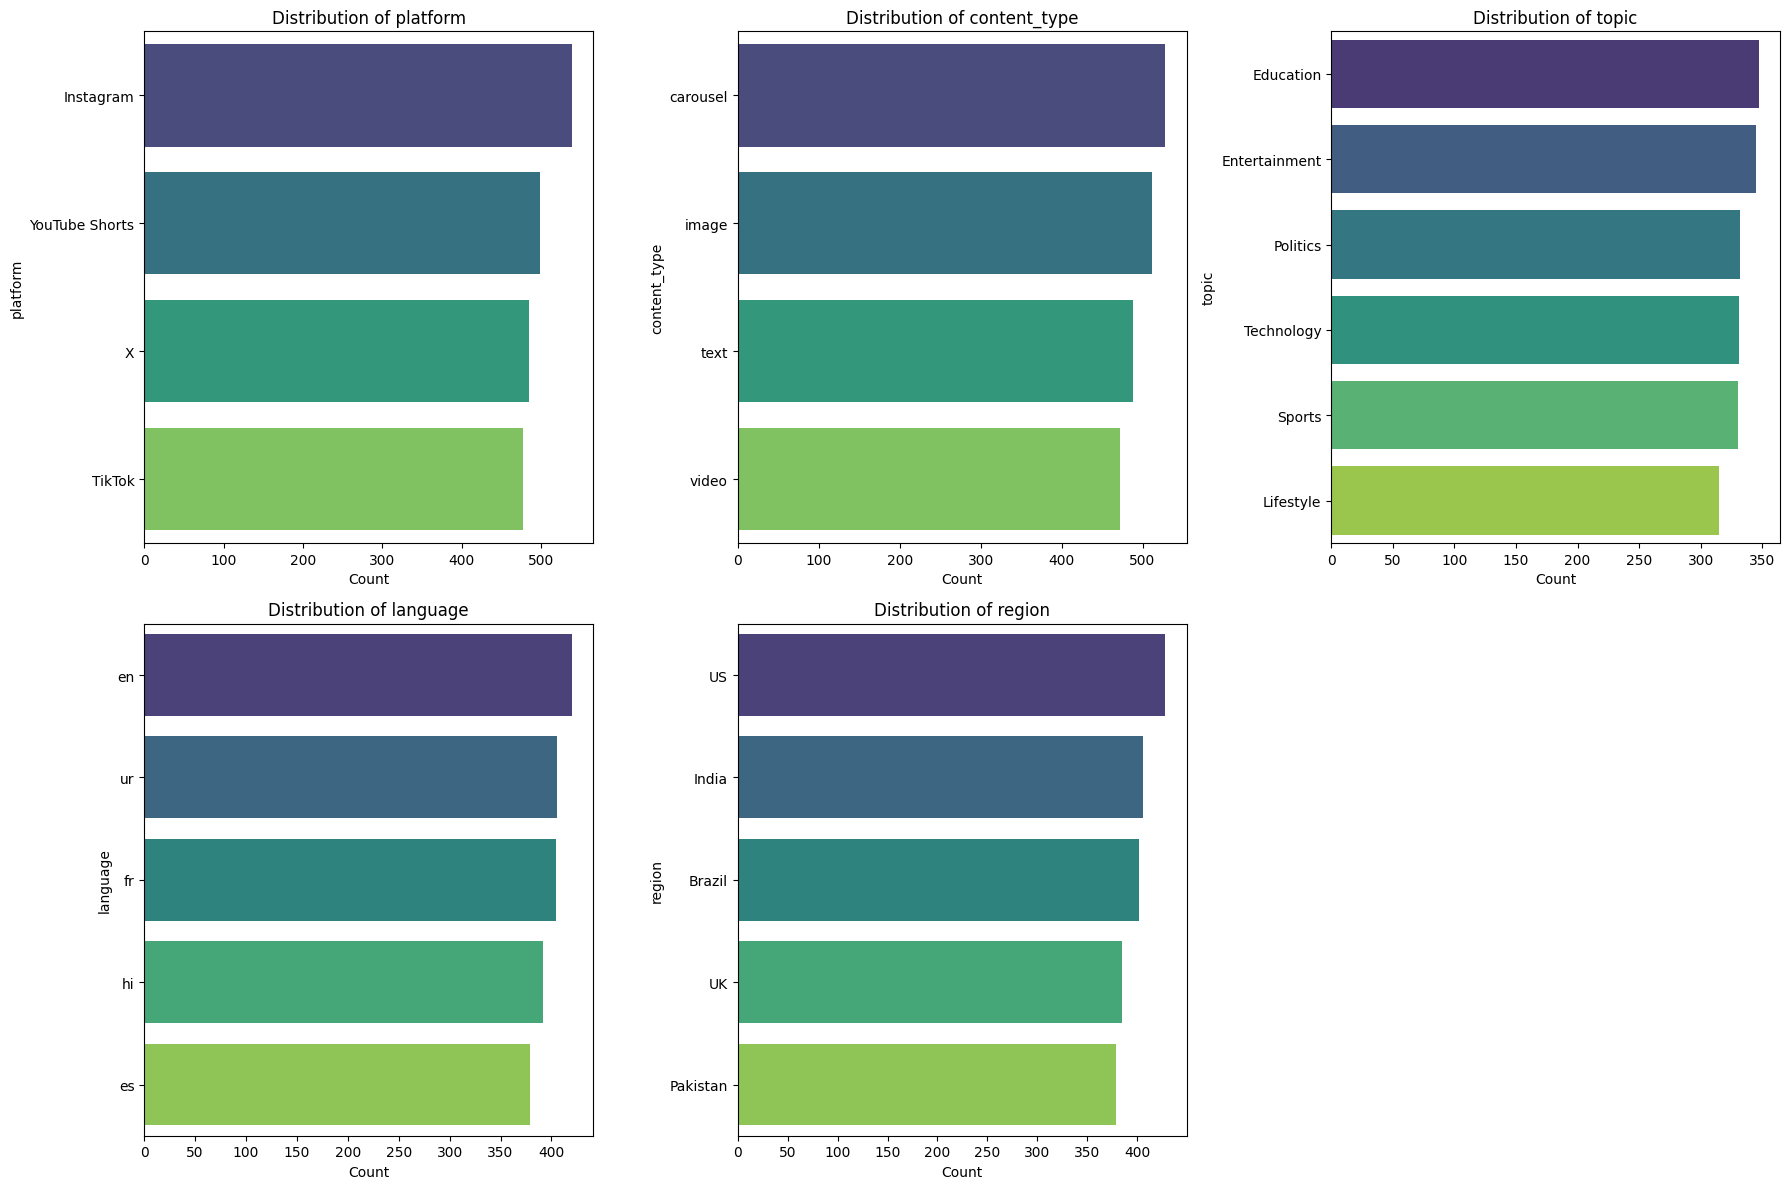

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features = ['platform', 'content_type', 'topic', 'language', 'region']

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_features):
    plt.subplot(2, 3, i + 1)
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

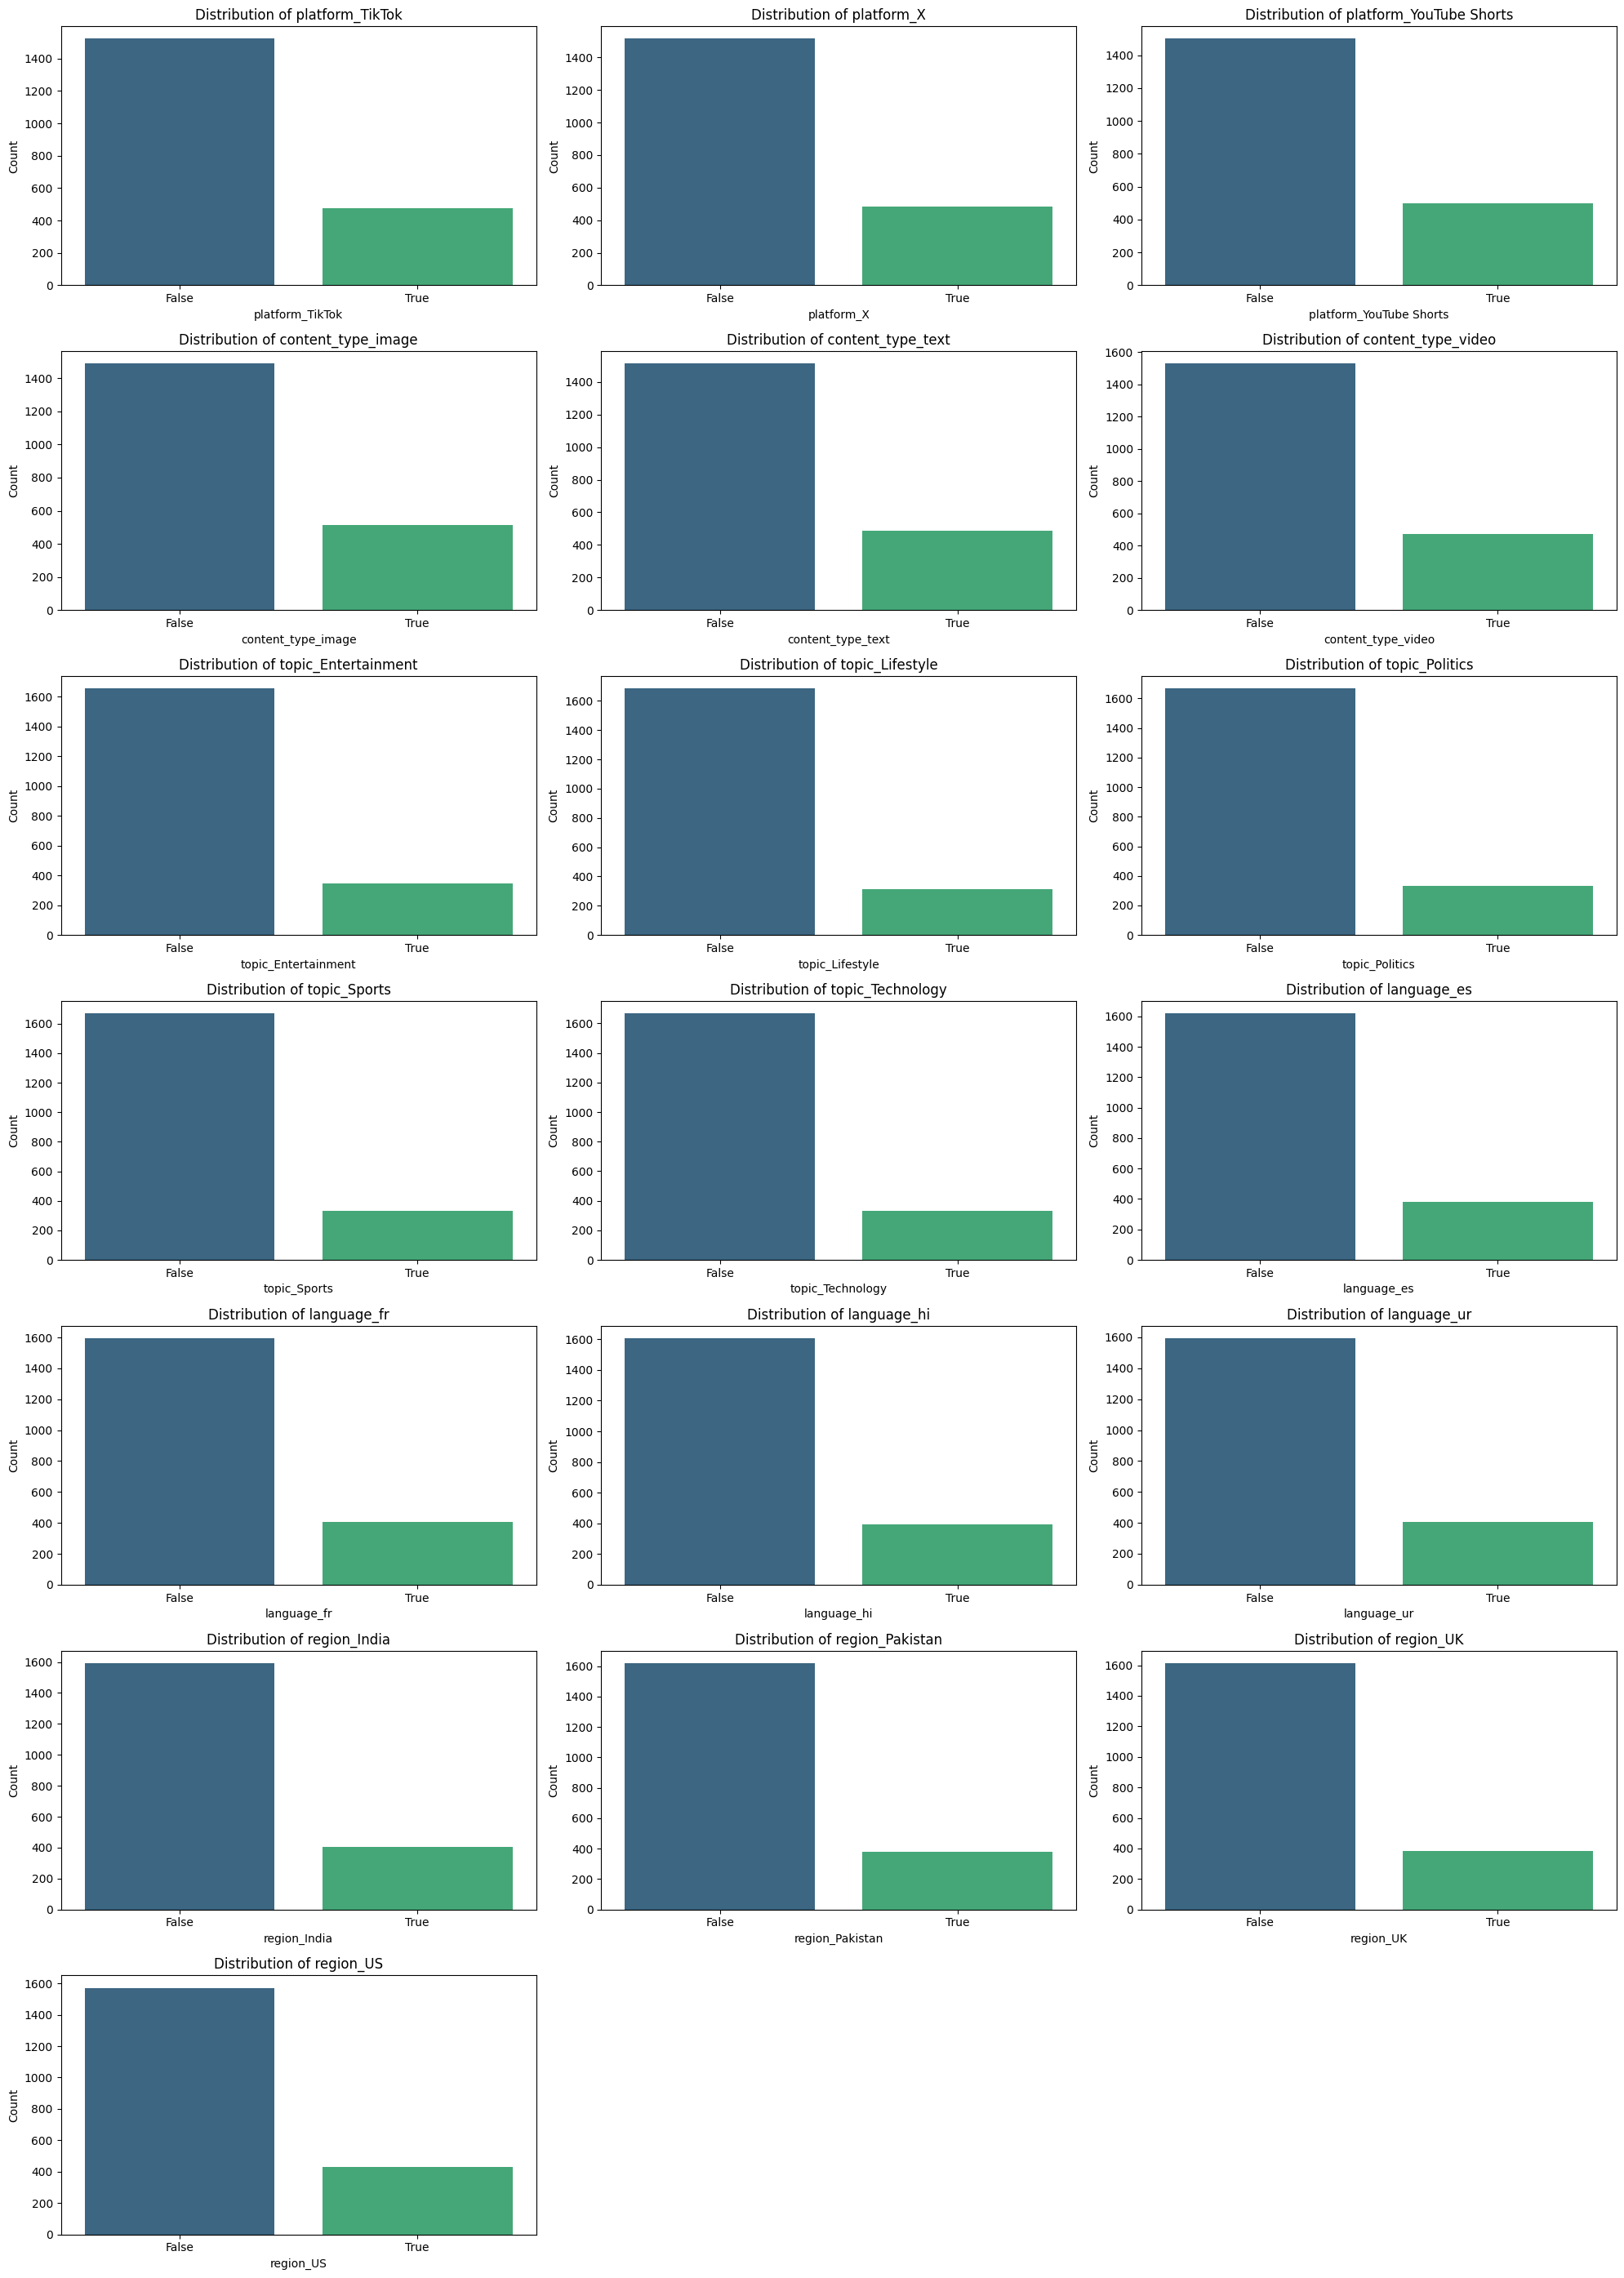

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Identify boolean columns (one-hot encoded features)
boolean_cols = df_encoded.select_dtypes(include=['bool']).columns.tolist()

# Filter out 'is_viral' if it's treated separately as a target/binary feature and not an encoded category for plotting here.
# 'is_viral' is a numerical feature after standardization, so it should not be in boolean_cols at this point.

# Collect all encoded columns to plot
all_encoded_cols_to_plot = []
# Grouping for conceptual organization, but for plotting, iterate over the consolidated list
for group_prefix in ['platform_', 'content_type_', 'topic_', 'language_', 'region_']:
    all_encoded_cols_to_plot.extend([col for col in boolean_cols if col.startswith(group_prefix)])

# Ensure 'is_viral' is not mistakenly included if it was ever boolean before standardization
if 'is_viral' in all_encoded_cols_to_plot:
    all_encoded_cols_to_plot.remove('is_viral')

num_plots = len(all_encoded_cols_to_plot)
num_cols_per_row = 3
num_rows = math.ceil(num_plots / num_cols_per_row)

# Create figure and axes using plt.subplots
fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(20, num_rows * 4))

# Flatten the axes array for easy iteration if it's multi-dimensional
if num_rows > 1 and num_cols_per_row > 1:
    axes = axes.flatten()
elif num_rows == 1 and num_cols_per_row > 1:
    # If only one row, axes is a 1D array, no flattening needed
    pass
elif num_cols_per_row == 1 and num_rows > 1:
    # If only one column, axes is a 1D array, no flattening needed
    pass
else: # Only one subplot (1x1 grid)
    axes = [axes] # Make it iterable

for i, col in enumerate(all_encoded_cols_to_plot):
    ax = axes[i] # Get the current axis
    sns.countplot(x=df_encoded[col], palette='viridis', hue=df_encoded[col], legend=False, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

# Hide any unused subplots
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Correlation Matrix Analysis

### Subtask:
Compute and visualize the correlation matrix for all features, including the new hashtag TF-IDF features. Pay special attention to the correlation of all features with the target column 'views' and the relationship between 'positive audience reactions' related features and 'views' to understand their linear relationships.


Correlation matrix computed for all features including TF-IDF.


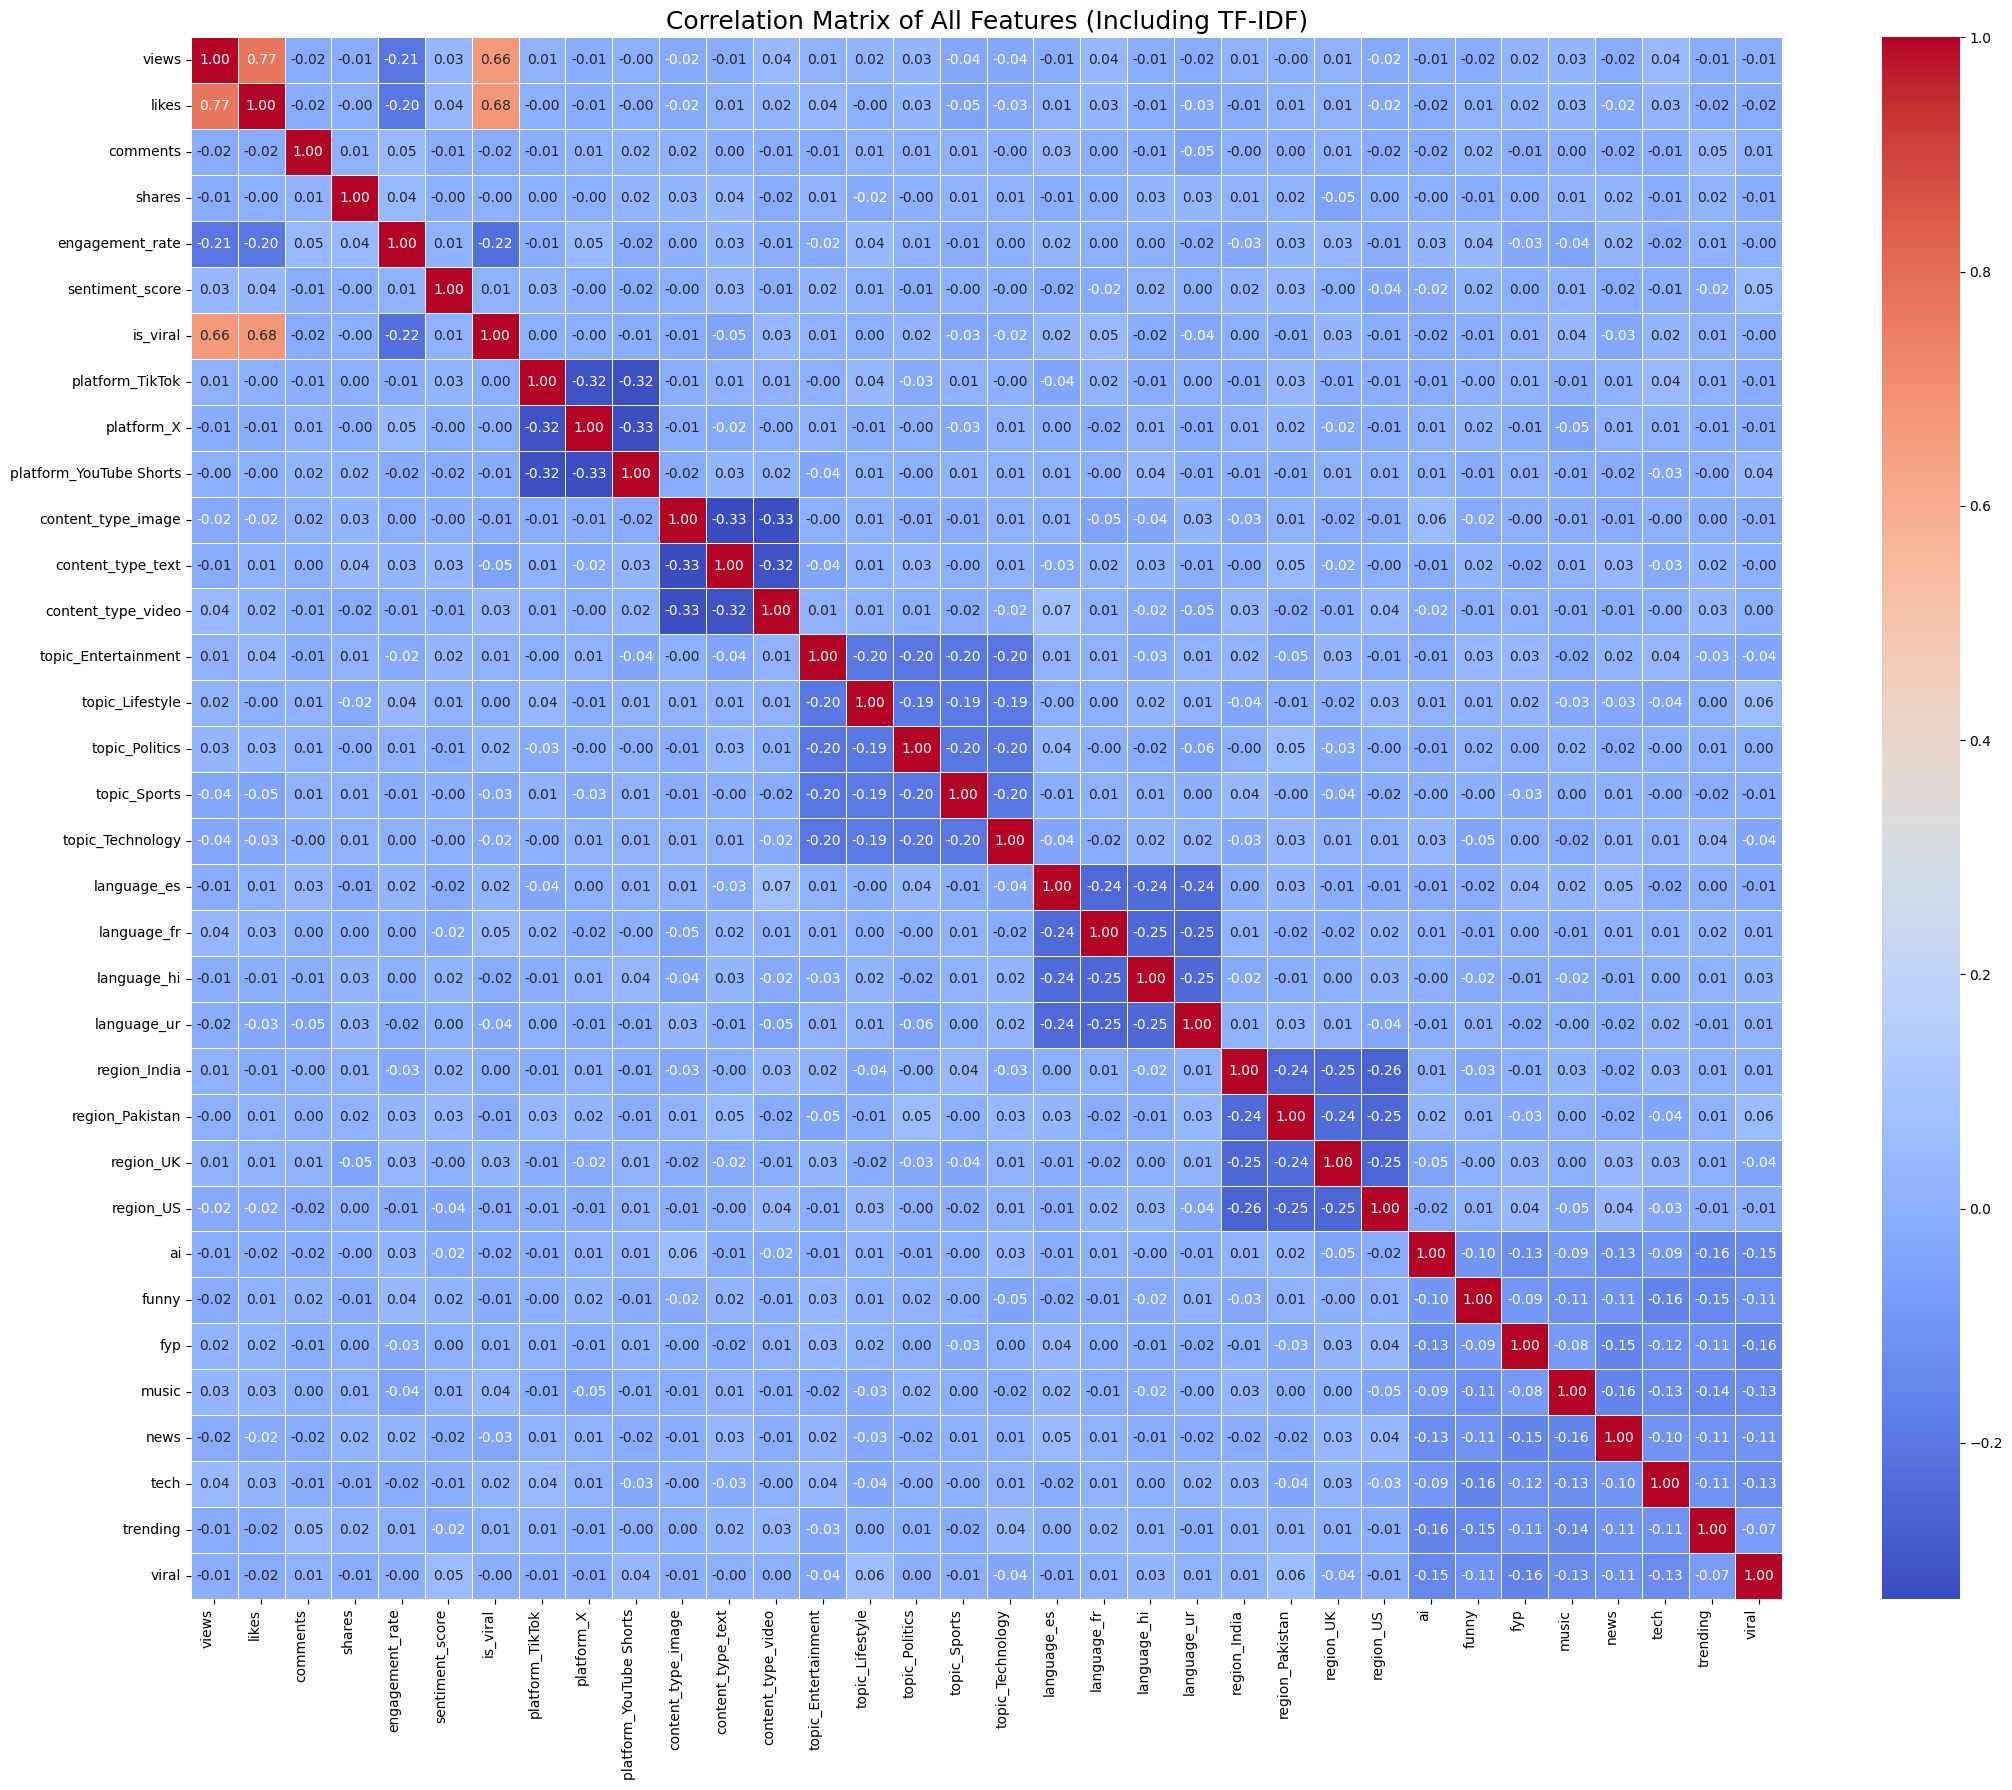


Correlations with 'views' column (sorted, including TF-IDF features):
views                      1.000000
likes                      0.774188
is_viral                   0.661532
tech                       0.042548
content_type_video         0.042381
language_fr                0.038613
sentiment_score            0.032827
topic_Politics             0.028581
music                      0.027559
fyp                        0.019102
topic_Lifestyle            0.017831
platform_TikTok            0.012759
topic_Entertainment        0.008118
region_India               0.007756
region_UK                  0.006265
region_Pakistan           -0.001982
platform_YouTube Shorts   -0.003856
language_hi               -0.006942
viral                     -0.008011
ai                        -0.009187
platform_X                -0.010357
language_es               -0.010624
trending                  -0.013196
shares                    -0.013583
content_type_text         -0.014753
language_ur               -0.

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select all numerical and boolean columns for correlation analysis
correlation_cols_all = df_encoded.select_dtypes(include=['int64', 'float64', 'bool']).columns.tolist()

# Exclude 'post_datetime' as it's a datetime object and not suitable for correlation with other numerical features
if 'post_datetime' in correlation_cols_all:
    correlation_cols_all.remove('post_datetime')

# Compute the correlation matrix
correlation_matrix_all = df_encoded[correlation_cols_all].corr()

print("Correlation matrix computed for all features including TF-IDF.")

# Set up the matplotlib figure
plt.figure(figsize=(22, 18))

# Create a heatmap of the correlation matrix
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Features (Including TF-IDF)', fontsize=18)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nCorrelations with 'views' column (sorted, including TF-IDF features):")
print(correlation_matrix_all['views'].sort_values(ascending=False))